# 1. Import Required Libraries

In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from mpl_toolkits.mplot3d import Axes3D  

# 2. PCA Implementation and Testing

This cell contains the full implementation of a custom PCA function along with a simple test to verify that it works correctly. The PCA function computes the mean vector, centers the data, forms the covariance matrix, extracts eigenvalues and eigenvectors, selects the top principal components, and projects the data onto this reduced space. After defining the function, a random dataset is generated to test the implementation, and the shapes of the outputs along with the variance explained by the selected components are printed to confirm that everything operates as expected.


In [3]:
def myPCA(X, m):
    # Compute the mean vector across samples
    mu = np.mean(X, axis=1, keepdims=True)
    # Center the data by subtracting the mean
    X_centered = X - mu 
    # Number of samples
    N = X.shape[1]
    # Compute the covariance matrix
    C = np.dot(X_centered, X_centered.T) / (N - 1)
    # Compute eigenvalues and eigenvectors of the covariance matrix
    eigenvalues, eigenvectors = np.linalg.eigh(C)
    # Sort eigenvalues in descending order
    idx = np.argsort(eigenvalues)[::-1]
    # Reorder eigenvalues and eigenvectors accordingly
    eigenvalues_sorted = eigenvalues[idx]
    eigenvectors_sorted = eigenvectors[:, idx]
    # Select the top m principal components
    U_m = eigenvectors_sorted[:, :m]
    lambdas_m = eigenvalues_sorted[:m]
    # Project the centered data onto the selected components
    Z = np.dot(U_m.T, X_centered)
    return U_m, lambdas_m, mu, Z
if __name__ == "__main__":
    # Example PCA usage with random data
    D, N = 5, 100
    X_example = np.random.randn(D, N)
    # Number of principal components to keep
    m = 2  
    U_m, lambdas_m, mu, Z = myPCA(X_example, m)
    # Print results to verify correct shapes and output
    print("U_m shape:", U_m.shape)
    print("lambdas_m:", lambdas_m)
    print("mu shape:", mu.shape)
    print("Z shape:", Z.shape)
    # Summing variance explained by the top components
    total_var_explained = np.sum(lambdas_m)
    print(f"Total variance explained by top {m} components: {total_var_explained:.4f}")

U_m shape: (5, 2)
lambdas_m: [1.2677633  1.09118802]
mu shape: (5, 1)
Z shape: (2, 100)
Total variance explained by top 2 components: 2.3590


# 3. PCA Processing on a Color Image

This cell performs a complete PCA pipeline on a color image. It begins by loading the input image, reshaping the pixel data into a format suitable for PCA, and applying the previously defined `myPCA` function to extract the dominant color components. After projecting the image into the PCA color space, the code normalizes the transformed channels to make them visually interpretable and reconstructs the image using the principal components. It then displays three visual outputs the original image, the PCA-based color representation, and the reconstructed image allowing you to compare the effect of decorrelating color channels. Finally, the mean squared error between the original and reconstructed images is computed as a quantitative measure of reconstruction quality.


Image loaded: size = 288x512, channels = 3
Eigenvalues (RGB): [8010.41148063  386.48085383   88.31288729]
U matrix (principal vectors):
 [[-0.59583827 -0.69711173  0.39876308]
 [-0.55061263 -0.00686331 -0.83473267]
 [-0.58463877  0.71692965  0.37974911]]


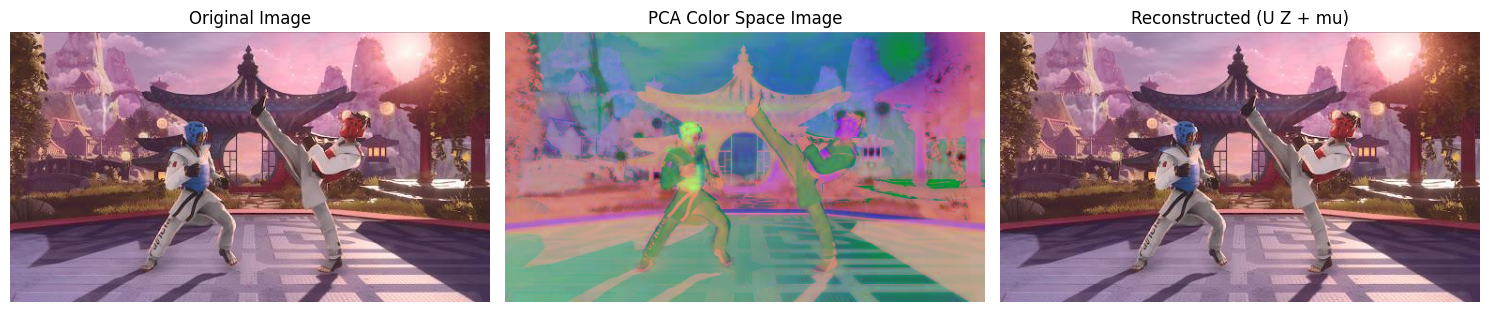

Reconstruction MSE (lower is better): 0.08 – If it's near zero, that's perfect!



Image loaded: size = 429x700, channels = 3
Eigenvalues (RGB): [8264.13409386  601.96279867   63.22359697]
U matrix (principal vectors):
 [[-0.54504625 -0.52433784 -0.65421283]
 [-0.52140551 -0.39906598  0.75424309]
 [-0.65655227  0.75220754 -0.05588322]]


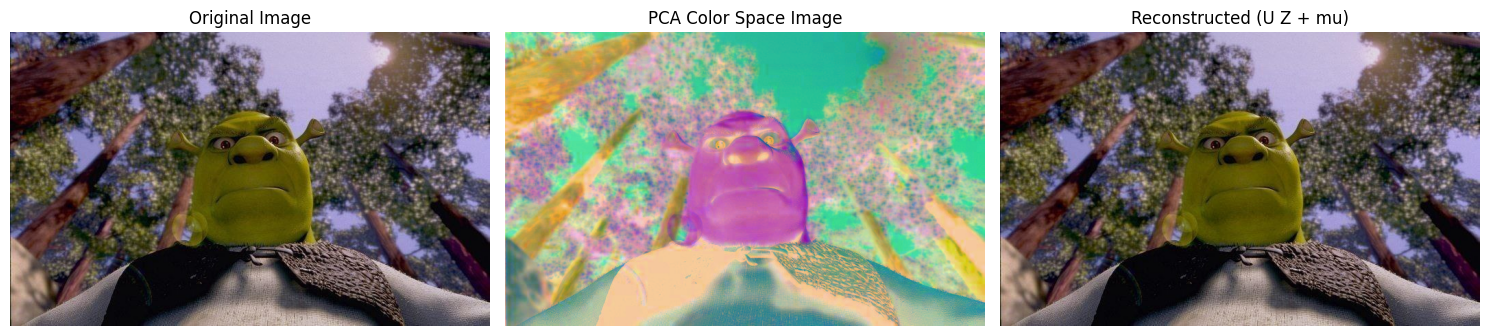

Reconstruction MSE (lower is better): 0.44 – If it's near zero, that's perfect!


In [ ]:
def pca_on_color_image_with_steps(image_path):
    # Load the image and force RGB mode
    original_img = np.array(Image.open(image_path).convert("RGB"))
    # Get spatial dimensions and number of channels
    height, width, channels = original_img.shape  
    print(f"Image loaded: size = {height}x{width}, channels = {channels}")
    # Reshape image to (channels, num_pixels) for PCA
    pixels_matrix = original_img.reshape(-1, channels).T  
    # Run PCA on the color pixels, keep 3 principal components
    principal_vectors, eigenvalues, mean_vector, projected_data = myPCA(pixels_matrix, m=3)
    print("Eigenvalues (RGB):", eigenvalues)
    print("U matrix (principal vectors):\n", principal_vectors)
    # Reshape projected data back to image format
    projected_image = projected_data.T.reshape(height, width, 3).astype(float)
    # Normalize each PCA channel independently to [0, 1]
    normalized_pca_image = np.zeros_like(projected_image)
    for channel_idx in range(3):
        channel_data = projected_image[:, :, channel_idx]
        min_val, max_val = channel_data.min(), channel_data.max()
        normalized_pca_image[:, :, channel_idx] = (channel_data - min_val) / (max_val - min_val + 1e-8)
    # Scale normalized PCA image to [0, 255] for visualization
    pca_color_display = (normalized_pca_image * 255).astype(np.uint8)
    # Create a figure with three panels: original, PCA color space, reconstructed
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))  
    # Show original image
    axes[0].imshow(original_img)
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    # Show PCA-based color image
    axes[1].imshow(pca_color_display)
    axes[1].set_title("PCA Color Space Image")
    axes[1].axis("off")
    # Reconstruct image from principal components: U Z + mu
    reconstructed_pixels = (principal_vectors @ projected_data + mean_vector).T.reshape(height, width, 3)
    reconstructed_img = np.clip(reconstructed_pixels, 0, 255).astype(np.uint8)
    # Show reconstructed image
    axes[2].imshow(reconstructed_img)
    axes[2].set_title("Reconstructed (U Z + mu)")
    axes[2].axis("off")
    # Adjust layout to avoid overlapping titles
    plt.tight_layout()
    # Save the figure using a name derived from the input file
    base_name = image_path.split('/')[-1].split('.')[0]  
    plt.savefig(f'pca_steps_result_{base_name}.png', dpi=150, bbox_inches='tight')  
    # Display the plots
    plt.show() 
    # Compute mean squared error between original and reconstructed image
    mse = np.mean((original_img - reconstructed_img) ** 2)
    print(f"Reconstruction MSE (lower is better): {mse:.2f} – If it's near zero, that's perfect!")
    return original_img, reconstructed_img, pca_color_display
if __name__ == "__main__":
    # Run PCA pipeline on the first image
    original_img1, recon_img1, pca_img1 = pca_on_color_image_with_steps("com.aprillcom.apih.taekwondo.korea.wllppr.wallpapertaekwondo-595cdcc2-fafa-4c63-a165-409620c87698.jpeg")
    print("\n\n")
    # Run PCA pipeline on the second image
    original_img2, recon_img2, pca_img2 = pca_on_color_image_with_steps("photo_2023-09-08_16-03-34.jpg")


# 4. PCA Visualization on YaleB Subject

This cell loads all grayscale `.tif` images of a single YaleB subject, assigns each image to one of the five official lighting subsets, and reshapes the images into 32×32 vectors. After forming the full data matrix, PCA is applied to extract the top three principal components. The projected data is then visualized in both 2D and 3D space, where each lighting subset is shown in a different color. This allows you to see how images taken under similar lighting conditions cluster together in the reduced-dimensional PCA space, giving an intuitive understanding of the structure of the dataset and the effect of illumination variations.


Person folder: B01P00
First 3 eigenvalues: [1604947.8  1377491.8   265572.25]


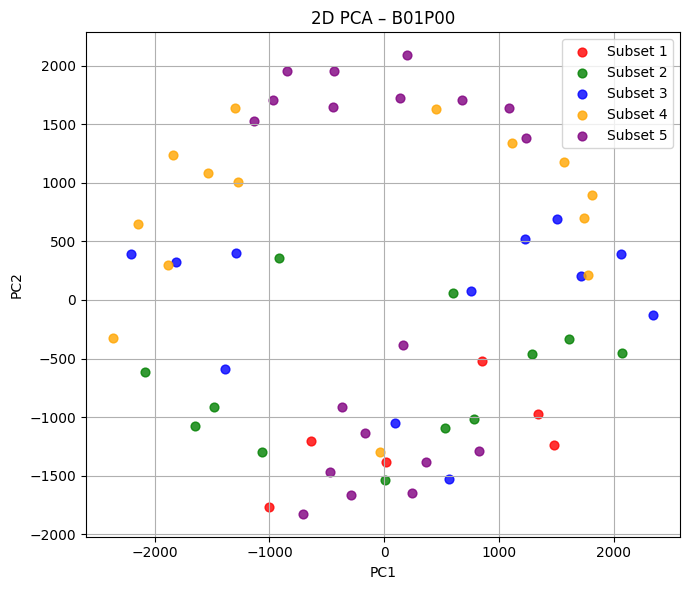

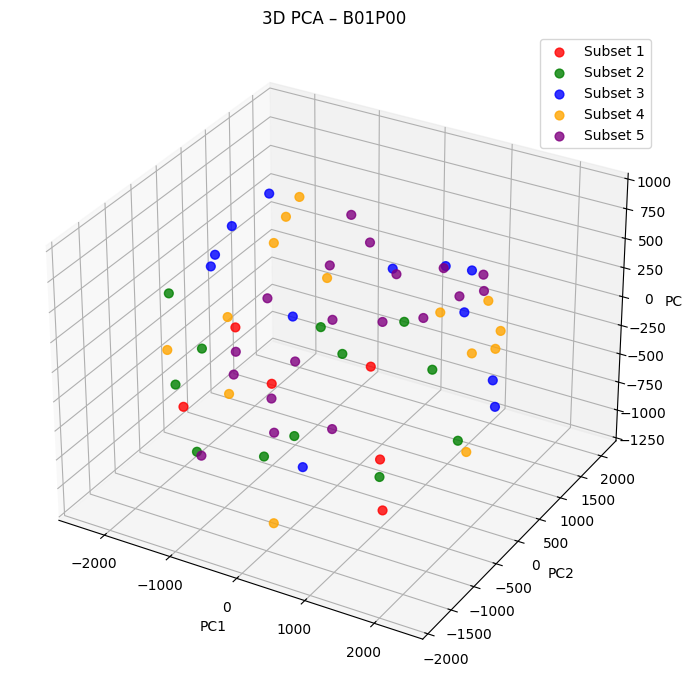

In [4]:
# Original subset indices as provided in the dataset documentation
subset1 = [1, 7, 8, 9, 36, 37]
subset2 = [2, 5, 10, 11, 12, 13, 15, 39, 40, 41, 42, 44]
subset3 = [3, 6, 14, 16, 17, 19, 20, 43, 45, 46, 48, 49]
subset4 = [18, 21, 22, 23, 24, 25, 26, 47, 50, 51, 52, 53, 54, 55]
subset5 = [4, 27, 28, 29, 30, 31, 32, 33, 34, 35, 56, 57, 58, 59, 60, 61, 62, 63, 64]
# Convert dataset indices to zero-based indexing
subset1 = [i - 1 for i in subset1]
subset2 = [i - 1 for i in subset2]
subset3 = [i - 1 for i in subset3]
subset4 = [i - 1 for i in subset4]
subset5 = [i - 1 for i in subset5]
def load_yaleb_person_tif(person_dir):
    # Collect all .tif files inside the given person's directory
    files = [f for f in os.listdir(person_dir) if f.lower().endswith(".tif")]
    # Sort files to maintain consistent ordering
    files = sorted(files)
    # Limit to the first 64 images
    files = files[:64]
    X_list = []
    labels = []
    # Loop through each file and assign it to a lighting subset
    for idx, fname in enumerate(files):
        path = os.path.join(person_dir, fname)
        # Load image in grayscale and convert to float
        img = np.array(Image.open(path).convert("L")).astype(float)
        # Resize to 32x32 to reduce dimensionality
        img32 = np.array(Image.fromarray(img).resize((32, 32)))
        # Flatten the resized image into a column vector
        vec = img32.reshape(-1, 1)
        X_list.append(vec)
        # Assign subset label based on index (zero-based)
        if idx in subset1:
            labels.append(1)
        elif idx in subset2:
            labels.append(2)
        elif idx in subset3:
            labels.append(3)
        elif idx in subset4:
            labels.append(4)
        elif idx in subset5:
            labels.append(5)
        else:
            # Should not happen if all subsets are defined correctly
            labels.append(0)
    # Stack all image vectors column-wise into a data matrix
    X = np.concatenate(X_list, axis=1)
    # Convert labels list to numpy array
    labels = np.array(labels)
    return X, labels
def visualize_yaleb_person_with_pca(person_dir):
    # Load flattened images and their subset labels for a single person
    X, labels = load_yaleb_person_tif(person_dir)  
    # Run PCA and keep the first 3 principal components
    U_m, lambdas_m, mu, Z = myPCA(X, m=3)   
    print(f"Person folder: {os.path.basename(person_dir)}")
    print("First 3 eigenvalues:", lambdas_m)
    # Take 2D and 3D projections from the PCA scores
    Z2 = Z[:2, :]  
    Z3 = Z[:3, :]  
    # Color mapping for each lighting subset
    colors = {
        1: "red",
        2: "green",
        3: "blue",
        4: "orange",
        5: "purple",
        0: "gray"   # Fallback label (should not appear ideally)
    }
    # 2D PCA visualization
    plt.figure(figsize=(7, 6))
    for s in [1, 2, 3, 4, 5]:
        # Select samples belonging to subset s
        mask = (labels == s)
        if np.any(mask):
            plt.scatter(
                Z2[0, mask], Z2[1, mask],
                s=40,
                label=f"Subset {s}",
                c=colors[s],
                alpha=0.8
            )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"2D PCA – {os.path.basename(person_dir)}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    # 3D PCA visualization 
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')
    for s in [1, 2, 3, 4, 5]:
        # Select samples belonging to subset s
        mask = (labels == s)
        if np.any(mask):
            ax.scatter(
                Z3[0, mask], Z3[1, mask], Z3[2, mask],
                s=40,
                label=f"Subset {s}",
                c=colors[s],
                alpha=0.8
            )
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.set_title(f"3D PCA – {os.path.basename(person_dir)}")
    ax.legend()
    plt.tight_layout()
    plt.show()
if __name__ == "__main__":
    # Example usage on a single person directory
    # If you want to run PCA visualization for all 10 people, uncomment the block below:
    # root_dir = "YaleB"
    # person_ids = [f"B{str(i).zfill(2)}P00" for i in range(1, 11)]
    # for pid in person_ids:
    #     person_dir = os.path.join(root_dir, pid)
    #     visualize_yaleb_person_with_pca(person_dir)
    # For now, just visualize PCA for a single subject
    visualize_yaleb_person_with_pca("YaleB\\B01P00")